In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
print(os.listdir(path))
df = pd.read_csv(path + '/PJME_hourly.csv', encoding='latin1')
df.head(10)

Using Colab cache for faster access to the 'hourly-energy-consumption' dataset.
['est_hourly.paruqet', 'DOM_hourly.csv', 'EKPC_hourly.csv', 'DUQ_hourly.csv', 'DAYTON_hourly.csv', 'PJME_hourly.csv', 'PJM_Load_hourly.csv', 'NI_hourly.csv', 'FE_hourly.csv', 'COMED_hourly.csv', 'AEP_hourly.csv', 'pjm_hourly_est.csv', 'DEOK_hourly.csv', 'PJMW_hourly.csv']


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
5,2002-12-31 06:00:00,26222.0
6,2002-12-31 07:00:00,28702.0
7,2002-12-31 08:00:00,30698.0
8,2002-12-31 09:00:00,31800.0
9,2002-12-31 10:00:00,32359.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [4]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 145366 entries, 2002-12-31 01:00:00 to 2018-01-02 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


Index(['PJME_MW'], dtype='object')

In [6]:
df.index.min(), df.index.max()

(Timestamp('2002-01-01 01:00:00'), Timestamp('2018-08-03 00:00:00'))

<Axes: xlabel='Datetime'>

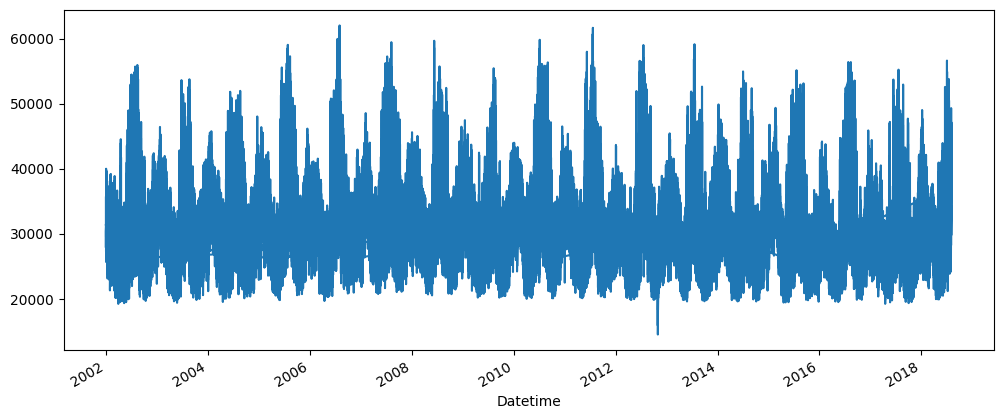

In [7]:
df['PJME_MW'].plot(figsize=(12, 5))

## Insight
Energy consumption fluctuates significantly through out time, showing clear patterns of peaks and drops. This suggests that energy demands are not constant and may follow daily or seasonal trends.

## Hypothesis
I presume that during the winter season, the demand for energy may be greater than the summer season, due to the cold weather, increased demand for heating would be expected.

<Axes: xlabel='month'>

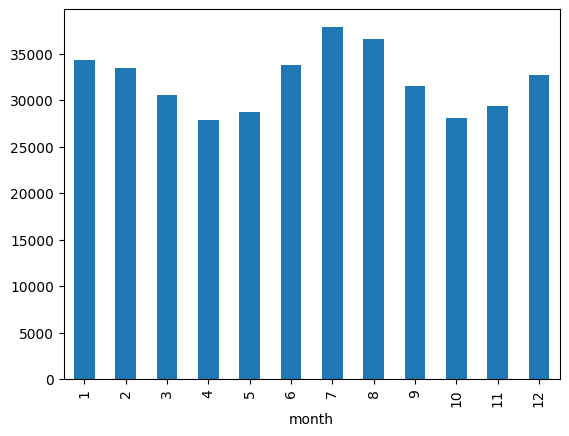

In [8]:
df['month'] = df.index.month
df.groupby('month')['PJME_MW'].mean().plot(kind='bar')

Contrary to the initial hypothesis, energy consumption is highest during the summer months, particularly July and August. This suggests that energy demand is driven more by other factors such as cooling systems (air conditioning) rather than heating. Seasonal temperature increases appear to significantly impact electricity usage. This highlights the importance of validating assumptions through data, as real world patterns may differ from expectations.

<Axes: xlabel='hour'>

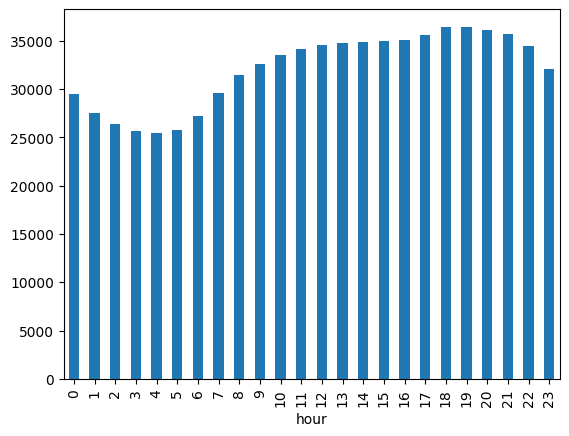

In [9]:
df['hour'] = df.index.hour
df.groupby('hour')['PJME_MW'].mean().plot(kind='bar')

## Insight
Energy consumption follows a clear daily pattern, starting to rise in the morning at around 8am, peaking in the early evening around 6-7pm, and then gradually declining overnight. This suggest that energy demand is strongly influenced by daily human activity cycles, with peak usage occuring when residential and commercial demand overlap.

<Axes: xlabel='Datetime'>

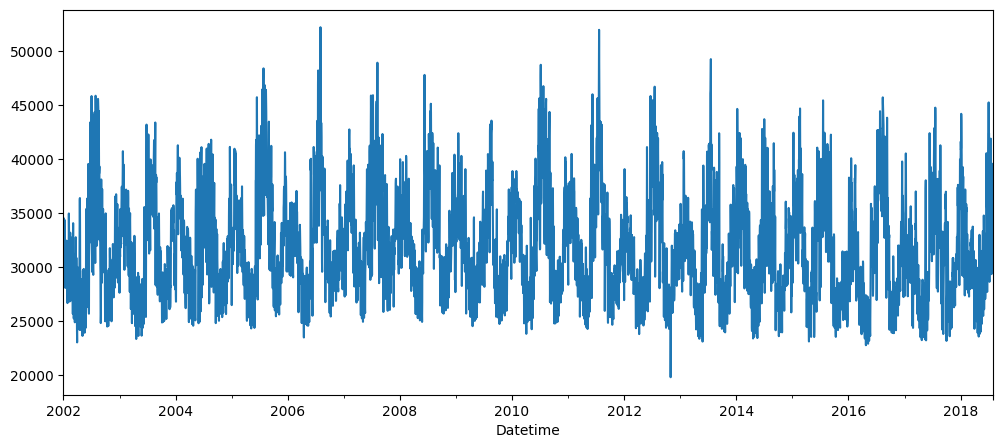

In [10]:
daily = df['PJME_MW'].resample('D').mean()
daily.plot(figsize=(12, 5))

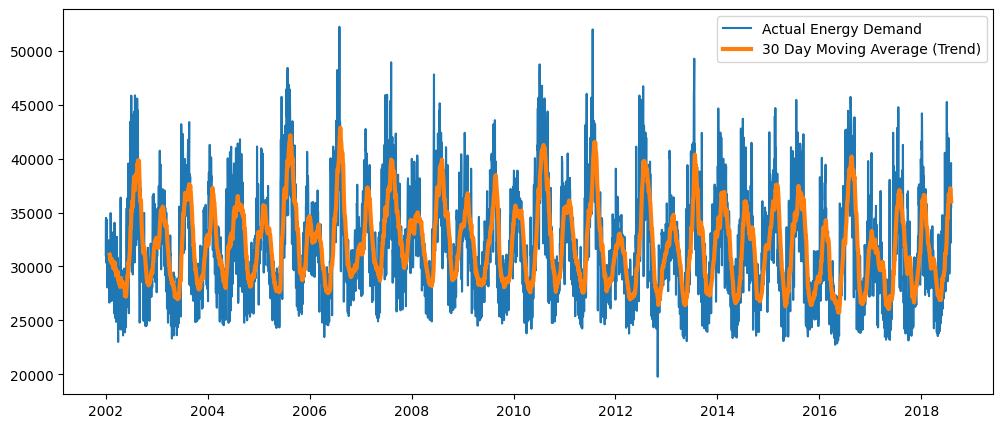

In [11]:
forecast = daily.rolling(window=30).mean()
plt.figure(figsize=(12, 5))
plt.plot(daily, label='Actual Energy Demand')
plt.plot(forecast, label='30 Day Moving Average (Trend)', linewidth=3)
plt.legend()
plt.show()

<Axes: xlabel='Datetime'>

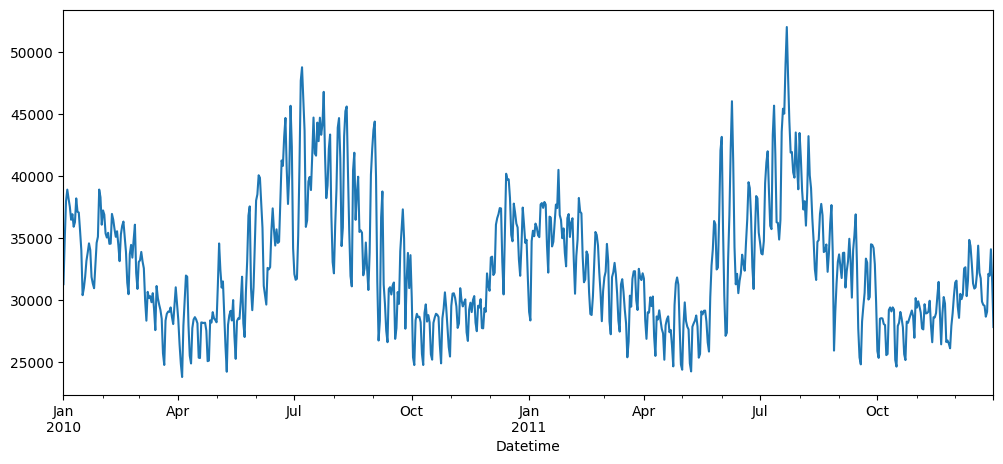

In [12]:
daily['2010':'2011'].plot(figsize=(12, 5))

#Forcasting Insight
A 30 day moving average was used to smooth energy demand data and idnetify underlying trends. The results show that whoile energy consumption fluctuates daily, the overall trend remains stable with periodic incraese.
This suggets that short term forecasting can help anticipate demand patterns andsupport better energy planning.

## Conclusion
Energy demand shows a clear seasonal and daily patterns , with peaks during summer months and during evening hours, A simple moving average forcast confirms stable long term trends, suggesting that historical data can be used to anticipate future demand pattens effectively.